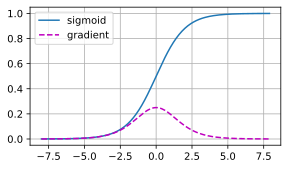

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x))

d2l.plot(x.detach().numpy(), [y.detach().numpy(), x.grad.numpy()],
         legend=['sigmoid', 'gradient'], figsize=(4.5, 2.5))

In [2]:
M = torch.normal(0, 1, size=(4,4))
print('一个矩阵 \n',M)

一个矩阵 
 tensor([[-0.4653, -0.3031,  0.2416,  1.1163],
        [-0.2419, -0.2214, -0.5820, -0.9510],
        [-1.1411,  0.0239, -0.4151, -0.2640],
        [-0.6421, -1.2690,  0.3605, -0.6784]])


In [3]:
import torch
from torch import nn
from torch.nn import functional as F

net = nn.Sequential(nn.Linear(20, 256), nn.ReLU(), nn.Linear(256, 10))

X = torch.rand(2, 20)
net(X)

tensor([[-0.0690,  0.0790,  0.2039,  0.0070,  0.3586,  0.0318,  0.2260, -0.0896,
         -0.0226,  0.2007],
        [-0.1292, -0.1127,  0.2424, -0.1058,  0.1508,  0.0364,  0.1818, -0.0310,
         -0.1870,  0.1318]], grad_fn=<AddmmBackward0>)

In [4]:
class MLP(nn.Module):
    # 用模型参数声明层。这里，我们声明两个全连接的层
    def __init__(self):
        # 调用MLP的父类Module的构造函数来执行必要的初始化。
        # 这样，在类实例化时也可以指定其他函数参数，例如模型参数params（稍后将介绍）
        super().__init__()
        self.hidden = nn.Linear(20, 256)  # 隐藏层
        self.out = nn.Linear(256, 10)  # 输出层

    # 定义模型的前向传播，即如何根据输入X返回所需的模型输出
    def forward(self, X):
        # 注意，这里我们使用ReLU的函数版本，其在nn.functional模块中定义。
        return self.out(F.relu(self.hidden(X)))
net = MLP()
net(X)

tensor([[-0.0132, -0.1979,  0.2363, -0.2931, -0.1664, -0.2663, -0.2911,  0.1694,
          0.0275, -0.0648],
        [-0.0236, -0.1103,  0.2194, -0.2273, -0.2744, -0.0728, -0.1011,  0.0856,
          0.1941, -0.0011]], grad_fn=<AddmmBackward0>)

In [5]:
class MySequential(nn.Module):
    def __init__(self, *args):
        super().__init__()
        for idx, module in enumerate(args):
            # 这里，module是Module子类的一个实例。我们把它保存在'Module'类的成员
            # 变量_modules中。_module的类型是OrderedDict
            self._modules[str(idx)] = module

    def forward(self, X):
        # OrderedDict保证了按照成员添加的顺序遍历它们
        for block in self._modules.values():
            X = block(X)
        return X
net = MySequential(nn.Linear(20, 256), nn.ReLU(), nn.Linear(256, 10))
net(X)

tensor([[ 0.0731, -0.0519, -0.1213, -0.1022, -0.2558,  0.2850,  0.2585, -0.1420,
         -0.1065, -0.1657],
        [ 0.1718, -0.0676, -0.0743,  0.0469, -0.3971,  0.2033,  0.3545, -0.1281,
         -0.2235, -0.1639]], grad_fn=<AddmmBackward0>)

In [8]:
import numpy as np
np.random.uniform(size=(20, 20))

array([[3.64710610e-01, 2.09630370e-01, 8.60597580e-01, 4.94658286e-01,
        9.39078340e-01, 5.08150163e-01, 1.45453303e-01, 6.28394522e-01,
        8.93358406e-01, 9.12909424e-01, 1.19874006e-01, 9.72234479e-01,
        2.79907327e-01, 7.39367855e-01, 2.77041306e-01, 6.93503294e-01,
        2.53084906e-01, 7.95023595e-01, 7.73448852e-01, 1.84582118e-02],
       [1.78399331e-01, 7.76083134e-01, 7.59835157e-01, 8.92745408e-01,
        5.62927748e-01, 1.52845154e-01, 1.03128104e-01, 1.11270767e-01,
        5.14483222e-01, 5.78199425e-01, 9.83538741e-01, 9.97221007e-01,
        2.45952027e-01, 1.61337297e-01, 9.23837713e-01, 2.59075858e-02,
        1.85512408e-01, 7.93837951e-01, 2.88283968e-02, 6.97326952e-01],
       [6.09220262e-01, 9.07863047e-02, 5.22705020e-01, 2.79782834e-01,
        5.96758946e-01, 4.54580799e-01, 1.45706534e-01, 5.12699376e-01,
        1.86726791e-01, 5.89979053e-01, 8.70005696e-01, 4.13026592e-01,
        8.79378833e-01, 9.80232295e-01, 1.04327054e-01, 8.5462

In [9]:
rand_weight = torch.rand((20, 20), requires_grad=False)

In [10]:
rand_weight

tensor([[5.9814e-02, 4.8901e-01, 8.1995e-01, 3.4859e-01, 5.7403e-01, 1.4596e-01,
         6.7987e-01, 5.1590e-01, 5.2540e-01, 3.7874e-01, 4.6978e-01, 5.4372e-01,
         6.7177e-01, 9.1653e-01, 5.5364e-01, 5.1386e-01, 6.9496e-02, 3.8041e-01,
         1.5869e-01, 5.6423e-01],
        [3.4946e-01, 2.9912e-01, 5.1881e-01, 5.2867e-01, 4.1725e-01, 3.4358e-01,
         3.4842e-01, 3.0622e-01, 7.0233e-01, 3.5930e-01, 2.1470e-01, 9.6218e-01,
         4.2174e-01, 7.8152e-01, 1.7648e-01, 2.4299e-01, 6.2980e-01, 6.9612e-01,
         2.8342e-01, 4.1912e-01],
        [2.6942e-01, 4.7432e-01, 2.8324e-01, 5.1182e-01, 5.1564e-01, 4.3170e-01,
         1.7244e-01, 6.0924e-01, 4.9451e-01, 1.9651e-01, 4.6854e-01, 6.3119e-01,
         6.8922e-01, 4.7589e-01, 8.9868e-01, 8.4143e-01, 5.8494e-01, 5.3806e-01,
         2.8845e-01, 4.8909e-01],
        [8.0514e-01, 3.3894e-01, 7.5049e-01, 8.8216e-01, 9.2006e-01, 3.3730e-01,
         6.3028e-01, 5.4454e-01, 2.8357e-01, 5.8856e-01, 5.0146e-01, 1.8533e-01,
       

In [11]:
torch.rand(2,20)

tensor([[0.0262, 0.0718, 0.9973, 0.8121, 0.1675, 0.0067, 0.5381, 0.0885, 0.6715,
         0.6965, 0.4992, 0.0249, 0.8986, 0.0981, 0.3089, 0.4534, 0.8645, 0.9339,
         0.0327, 0.2134],
        [0.6284, 0.7985, 0.2735, 0.7755, 0.4702, 0.2494, 0.5895, 0.3831, 0.9196,
         0.9616, 0.6444, 0.3816, 0.2846, 0.8026, 0.2801, 0.0585, 0.4141, 0.9407,
         0.9673, 0.3968]])

In [13]:
class FixedHiddenMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 不计算梯度的随机权重参数。因此其在训练期间保持不变
        self.rand_weight = torch.rand((20, 20), requires_grad=False)
        self.linear = nn.Linear(20, 20)

    def forward(self, X):
        X = self.linear(X)
        # 使用创建的常量参数以及relu和mm函数
        X = F.relu(torch.mm(X, self.rand_weight) + 1)
        # 复用全连接层。这相当于两个全连接层共享参数
        X = self.linear(X)
        # 控制流
        while X.abs().sum() > 1:
            X /= 2
        return X.sum()

In [14]:
class NestMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(20, 64), nn.ReLU(),
                                 nn.Linear(64, 32), nn.ReLU())
        self.linear = nn.Linear(32, 16)

    def forward(self, X):
        return self.linear(self.net(X))

chimera = nn.Sequential(NestMLP(), nn.Linear(16, 20), FixedHiddenMLP())
chimera(X)

tensor(-0.1272, grad_fn=<SumBackward0>)

In [16]:
import torch
from torch import nn
net = nn.Sequential(nn.Linear(4,8), nn.ReLU(), nn.Linear(8,1))
X = torch.rand(size=(2,4))
X

tensor([[0.0829, 0.7798, 0.3170, 0.3012],
        [0.0459, 0.9000, 0.3077, 0.4626]])

In [17]:
net

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

In [18]:
net(X)

tensor([[0.1308],
        [0.1364]], grad_fn=<AddmmBackward0>)

In [19]:
net[2].state_dict()

OrderedDict([('weight',
              tensor([[-0.0126, -0.2104, -0.3320, -0.1450,  0.3235, -0.3346,  0.2828,  0.0515]])),
             ('bias', tensor([0.1777]))])

In [20]:
X

tensor([[0.0829, 0.7798, 0.3170, 0.3012],
        [0.0459, 0.9000, 0.3077, 0.4626]])

In [21]:
nn.Linear(4,8)(X)

tensor([[ 0.3070, -0.5731, -0.0812, -0.3227,  0.0582, -0.6965,  0.7667,  0.6706],
        [ 0.3421, -0.6789, -0.1454, -0.4460,  0.0307, -0.7528,  0.8156,  0.7458]],
       grad_fn=<AddmmBackward0>)

In [22]:
net[2]

Linear(in_features=8, out_features=1, bias=True)

In [23]:
print(type(net[2].bias))

<class 'torch.nn.parameter.Parameter'>


In [24]:
net[2].bias

Parameter containing:
tensor([0.1777], requires_grad=True)

In [25]:
print(net[2].bias.data)

tensor([0.1777])


In [26]:
print(net[2].bias.grad)

None


In [27]:
net[2].weight.grad == None

True

In [28]:
net[2].weight

Parameter containing:
tensor([[-0.0126, -0.2104, -0.3320, -0.1450,  0.3235, -0.3346,  0.2828,  0.0515]],
       requires_grad=True)

In [29]:
print(*[(name, param.shape) for name, param in net[0].named_parameters()])
print(*[(name, param.shape) for name, param in net.named_parameters()])

('weight', torch.Size([8, 4])) ('bias', torch.Size([8]))
('0.weight', torch.Size([8, 4])) ('0.bias', torch.Size([8])) ('2.weight', torch.Size([1, 8])) ('2.bias', torch.Size([1]))


In [30]:
net.state_dict()['2.bias'].data

tensor([0.1777])

In [31]:
net

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

In [32]:
def my_init(m):
    if type(m) == nn.Linear:
        print("Init", *[(name, param.shape)
                        for name, param in m.named_parameters()][0])
        nn.init.uniform_(m.weight, -10, 10)
        m.weight.data *= m.weight.data.abs() >= 5

net.apply(my_init)


Init weight torch.Size([8, 4])
Init weight torch.Size([1, 8])


Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

In [33]:
net

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

In [35]:
net[0].weight.data[0]

tensor([7.8294, 0.0000, 0.0000, 0.0000])

In [36]:
net[2].weight.data[0]

tensor([ 0.0000, -9.9765, -9.2214,  0.0000,  8.6360,  0.0000,  0.0000, -0.0000])

In [37]:
net[0].weight.data[1]

tensor([ 0.0000,  0.0000,  6.1373, -9.6718])

In [39]:
net[0].bias.data

tensor([ 0.3509, -0.4296,  0.2005, -0.4828, -0.2700,  0.4546,  0.4923, -0.0795])

In [40]:
net[2].bias.data

tensor([0.1777])

In [41]:
def init_normal(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, mean=0, std=0.01)
        nn.init.zeros_(m.bias)
net.apply(init_normal)


Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

In [42]:
net[0].weight.data[0]

tensor([ 0.0084, -0.0050,  0.0048, -0.0079])

In [43]:
net[2].weight.data[0]

tensor([-0.0070,  0.0032, -0.0021, -0.0069,  0.0063,  0.0072, -0.0021, -0.0079])

In [44]:
net[0].bias.data

tensor([0., 0., 0., 0., 0., 0., 0., 0.])

In [45]:
net[2].bias.data

tensor([0.])

In [46]:
def init_constant(m):
    if type(m) == nn.Linear:
        nn.init.constant_(m.weight, 1)
        nn.init.zeros_(m.bias)
net.apply(init_constant)
net[0].weight.data[0], net[0].bias.data[0]

(tensor([1., 1., 1., 1.]), tensor(0.))

In [47]:
net[2].bias.data

tensor([0.])

In [48]:
def init_xavier(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
def init_42(m):
    if type(m) == nn.Linear:
        nn.init.constant_(m.weight, 42)

net[0].apply(init_xavier)
net[2].apply(init_42)
print(net[0].weight.data[0])
print(net[2].weight.data)

tensor([ 0.2941,  0.6557, -0.2647,  0.1789])
tensor([[42., 42., 42., 42., 42., 42., 42., 42.]])


In [49]:
import torch
from torch import nn

"""延后初始化"""
net = nn.Sequential(nn.LazyLinear(256), nn.ReLU(), nn.LazyLinear(10))
# print(net[0].weight)  # 尚未初始化
print(net)

X = torch.rand(2, 20)
net(X)
print(net)

Sequential(
  (0): LazyLinear(in_features=0, out_features=256, bias=True)
  (1): ReLU()
  (2): LazyLinear(in_features=0, out_features=10, bias=True)
)
Sequential(
  (0): Linear(in_features=20, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=10, bias=True)
)


In [50]:
import torch
import torch.nn.functional as F
from torch import nn


class CenteredLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, X):
        return X - X.mean()

In [51]:
layer = CenteredLayer()
layer(torch.FloatTensor([1, 2, 3, 4, 5]))

tensor([-2., -1.,  0.,  1.,  2.])